In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
import matplotlib.pyplot as plt

In [2]:
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [3]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [4]:
y_proba = model.predict_proba(X_test)[:, 1]

In [5]:
y_proba

array([0.97, 0.  , 0.  , 0.99, 1.  , 0.  , 0.  , 0.16, 0.35, 0.94, 0.94,
       0.02, 0.93, 0.12, 0.99, 0.01, 0.95, 1.  , 1.  , 0.  , 0.85, 1.  ,
       0.  , 1.  , 1.  , 0.92, 1.  , 0.96, 1.  , 0.  , 1.  , 0.99, 0.77,
       0.98, 1.  , 1.  , 0.24, 0.98, 0.  , 0.9 , 1.  , 0.02, 1.  , 1.  ,
       0.78, 0.99, 0.93, 0.96, 0.99, 0.97, 0.02, 0.  , 0.8 , 0.87, 1.  ,
       0.99, 1.  , 0.  , 0.29, 1.  , 0.99, 0.  , 0.  , 0.92, 1.  , 0.83,
       0.  , 0.  , 1.  , 1.  , 0.16, 0.01, 0.99, 0.  , 0.98, 0.96, 0.92,
       0.71, 1.  , 0.96, 0.01, 1.  , 0.74, 0.01, 0.15, 0.  , 0.07, 0.  ,
       0.98, 0.99, 0.99, 0.8 , 0.77, 0.92, 1.  , 1.  , 0.  , 0.01, 1.  ,
       0.01, 0.09, 1.  , 0.  , 0.  , 0.98, 0.98, 0.99, 0.  , 0.58, 0.87,
       0.02, 1.  , 0.71, 0.  ])

In [6]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

In [7]:
fpr

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.02325581, 0.02325581, 0.02325581, 0.02325581,
       0.02325581, 0.04651163, 0.06976744, 0.06976744, 0.11627907,
       0.1627907 , 0.25581395, 0.34883721, 0.48837209, 1.        ])

In [8]:
tpr

array([0.        , 0.38028169, 0.53521127, 0.61971831, 0.64788732,
       0.70422535, 0.71830986, 0.77464789, 0.83098592, 0.84507042,
       0.87323944, 0.87323944, 0.88732394, 0.91549296, 0.92957746,
       0.95774648, 0.95774648, 0.97183099, 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ])

In [9]:
roc_auc = auc(fpr, tpr)

In [10]:
roc_auc

0.9952505732066819

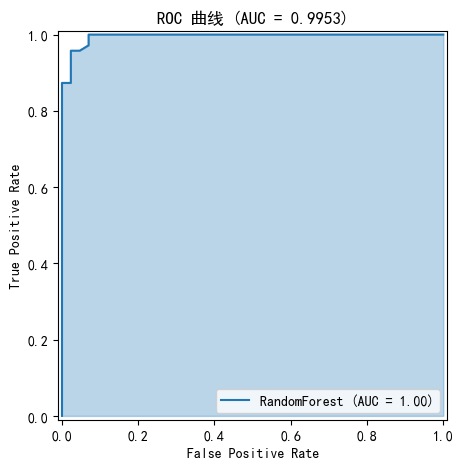

In [13]:
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name="RandomForest").plot()
plt.fill_between(fpr, tpr, alpha=0.3, color="#1f77b4", label=f"AUC 区域 (AUC={roc_auc:.4f})")
plt.title(f"ROC 曲线 (AUC = {roc_auc:.4f})")
plt.tight_layout()
plt.show()